# Clase 2 — Adquisición de datos e Inspección y visualización de datos

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import io

np.random.seed(42)
pd.set_option("display.max_columns", None)


## Ejercicio 1

Se simula el escenario de un proyecto de análisis de mercado para una empresa de comercio electrónico, en el que la información de ventas, clientes e inventario proviene de tres fuentes distintas: un archivo CSV, un archivo JSON y una hoja de cálculo Excel. A continuación se generan estos tres archivos con datos sintéticos y luego se importan con Pandas.


### Generación de los archivos de origen

Se generan de forma programática los tres archivos que pide la consigna: `ventas.csv`, `clientes.json` e `inventario.xlsx`. Los datos son sintéticos, pero mantienen relaciones coherentes entre sí (los `id_cliente` y `id_producto` de las ventas existen en las tablas de clientes e inventario, respectivamente).


In [2]:
# --- Tabla de clientes ---
n_clientes = 15
clientes = pd.DataFrame({
    "id_cliente": range(1, n_clientes + 1),
    "nombre": [f"Cliente_{i}" for i in range(1, n_clientes + 1)],
    "email": [f"cliente{i}@correo.com" for i in range(1, n_clientes + 1)],
    "ciudad": np.random.choice(
        ["Buenos Aires", "Córdoba", "Rosario", "Mendoza", "Tucumán"], n_clientes
    ),
})

clientes.to_json("../Datos/clientes.json", orient="records", force_ascii=False, indent=2)
clientes.head()


,id_cliente,nombre,email,ciudad
0,1,Cliente_1,cliente1@correo.com,Mendoza
1,2,Cliente_2,cliente2@correo.com,Tucumán
2,3,Cliente_3,cliente3@correo.com,Rosario
3,4,Cliente_4,cliente4@correo.com,Tucumán
4,5,Cliente_5,cliente5@correo.com,Tucumán


In [3]:
# --- Tabla de inventario ---
productos = ["Notebook", "Mouse", "Teclado", "Monitor", "Auriculares",
             "Silla gamer", "Webcam", "Impresora", "Router", "Tablet"]

inventario = pd.DataFrame({
    "id_producto": range(1, len(productos) + 1),
    "producto": productos,
    "categoria": ["Tecnología"] * len(productos),
    "precio_unitario": np.round(np.random.uniform(5000, 350000, len(productos)), 2),
    "stock": np.random.randint(0, 200, len(productos)),
})

inventario.to_excel("../Datos/inventario.xlsx", index=False)
inventario.head()


,id_producto,producto,categoria,precio_unitario,stock
0,1,Notebook,Tecnología,328800.68,187
1,2,Mouse,Tecnología,5268.67,14
2,3,Teclado,Tecnología,347312.99,189
3,4,Monitor,Tecnología,218031.12,189
4,5,Auriculares,Tecnología,216020.34,174


In [4]:
# --- Tabla de ventas ---
n_ventas = 60
fechas = pd.date_range("2026-01-01", periods=120, freq="D")

ventas = pd.DataFrame({
    "id_venta": range(1, n_ventas + 1),
    "fecha": np.random.choice(fechas, n_ventas),
    "id_cliente": np.random.randint(1, n_clientes + 1, n_ventas),
    "id_producto": np.random.randint(1, len(productos) + 1, n_ventas),
    "cantidad": np.random.randint(1, 5, n_ventas),
})
ventas = ventas.merge(inventario[["id_producto", "precio_unitario"]], on="id_producto")
ventas["total"] = ventas["cantidad"] * ventas["precio_unitario"]
ventas = ventas.sort_values("id_venta").reset_index(drop=True)

ventas.to_csv("../Datos/ventas.csv", index=False)
ventas.head()


,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,total
0,1,2026-01-03,15,1,4,328800.68,1315202.72
1,2,2026-04-11,5,5,1,216020.34,216020.34
2,3,2026-02-20,8,10,3,21099.65,63298.95
3,4,2026-01-07,10,7,1,12956.54,12956.54
4,5,2026-01-21,9,7,2,12956.54,25913.08


### Carga de datos de ventas desde CSV

In [5]:
ventas_csv = pd.read_csv("../Datos/ventas.csv")
ventas_csv.head()


,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,total
0,1,2026-01-03,15,1,4,328800.68,1315202.72
1,2,2026-04-11,5,5,1,216020.34,216020.34
2,3,2026-02-20,8,10,3,21099.65,63298.95
3,4,2026-01-07,10,7,1,12956.54,12956.54
4,5,2026-01-21,9,7,2,12956.54,25913.08


### Carga de datos de clientes desde JSON

In [6]:
with open("../Datos/clientes.json", "r", encoding="utf-8") as f:
    clientes_json_raw = json.load(f)

clientes_json = pd.DataFrame(clientes_json_raw)
cantidad_clientes = len(clientes_json)
print(f"Cantidad total de clientes: {cantidad_clientes}")
clientes_json.head()


Cantidad total de clientes: 15


,id_cliente,nombre,email,ciudad
0,1,Cliente_1,cliente1@correo.com,Mendoza
1,2,Cliente_2,cliente2@correo.com,Tucumán
2,3,Cliente_3,cliente3@correo.com,Rosario
3,4,Cliente_4,cliente4@correo.com,Tucumán
4,5,Cliente_5,cliente5@correo.com,Tucumán


### Carga de datos de inventario desde Excel

In [7]:
inventario_excel = pd.read_excel("../Datos/inventario.xlsx")
promedio_stock = inventario_excel["stock"].mean()
print(f"Promedio de stock disponible: {promedio_stock:.2f} unidades")
inventario_excel


Promedio de stock disponible: 121.60 unidades


,id_producto,producto,categoria,precio_unitario,stock
0,1,Notebook,Tecnología,328800.68,187
1,2,Mouse,Tecnología,5268.67,14
2,3,Teclado,Tecnología,347312.99,189
3,4,Monitor,Tecnología,218031.12,189
4,5,Auriculares,Tecnología,216020.34,174
5,6,Silla gamer,Tecnología,7437.88,189
6,7,Webcam,Tecnología,12956.54,50
7,8,Impresora,Tecnología,186047.26,107
8,9,Router,Tecnología,142952.04,54
9,10,Tablet,Tecnología,21099.65,63


### Combinación de las tres fuentes en una única estructura

Se combinan las tres tablas en un único DataFrame, uniendo las ventas con los datos del cliente que realizó la compra y con los datos del producto vendido.


In [8]:
ventas_completas = (
    ventas_csv
    .merge(clientes_json, on="id_cliente", how="left")
    .merge(inventario_excel[["id_producto", "producto", "categoria"]], on="id_producto", how="left")
)

ventas_completas.head()


,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,total,nombre,email,ciudad,producto,categoria
0,1,2026-01-03,15,1,4,328800.68,1315202.72,Cliente_15,cliente15@correo.com,Mendoza,Notebook,Tecnología
1,2,2026-04-11,5,5,1,216020.34,216020.34,Cliente_5,cliente5@correo.com,Tucumán,Auriculares,Tecnología
2,3,2026-02-20,8,10,3,21099.65,63298.95,Cliente_8,cliente8@correo.com,Rosario,Tablet,Tecnología
3,4,2026-01-07,10,7,1,12956.54,12956.54,Cliente_10,cliente10@correo.com,Tucumán,Webcam,Tecnología
4,5,2026-01-21,9,7,2,12956.54,25913.08,Cliente_9,cliente9@correo.com,Rosario,Webcam,Tecnología


In [9]:
# Resumen general de ventas por ciudad
ventas_por_ciudad = ventas_completas.groupby("ciudad")["total"].sum().sort_values(ascending=False)
ventas_por_ciudad


ciudad
Rosario    10262681.87
Mendoza     6944937.06
Tucumán     6142373.26
Córdoba     2222577.92
Name: total, dtype: float64

## Ejercicio 2

Se trabaja con el conjunto de datos `Automobile.csv`, que contiene características de automóviles utilizadas históricamente para predecir su consumo de combustible (columnas `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin`, con `origin` codificado como 1 = Estados Unidos, 2 = Europa, 3 = Asia). El archivo `Automobile.csv` debe estar guardado en la misma carpeta que este notebook.


### Carga del conjunto de datos

In [10]:
autos = pd.read_csv("../Datos/Automobile.csv")
print(f"Dimensiones del dataset: {autos.shape[0]} filas, {autos.shape[1]} columnas")
autos.head()


Dimensiones del dataset: 392 filas, 8 columnas


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [11]:
autos.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


### Gráfico de dispersión: `mpg` vs. `weight`

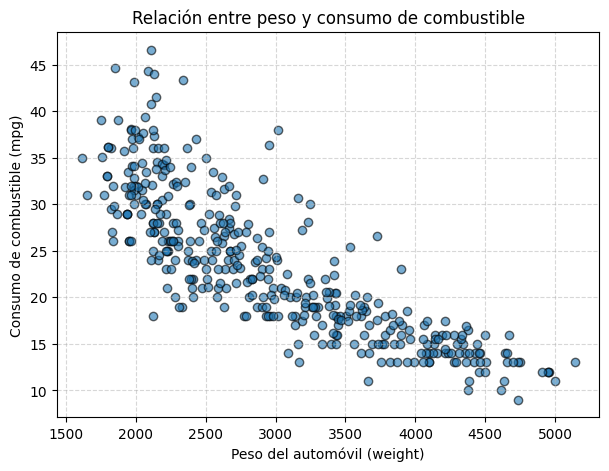

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(autos["weight"], autos["mpg"], alpha=0.6, edgecolor="black")
plt.xlabel("Peso del automóvil (weight)")
plt.ylabel("Consumo de combustible (mpg)")
plt.title("Relación entre peso y consumo de combustible")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


**Interpretación:** existe una relación negativa clara entre el peso del automóvil y su rendimiento en millas por galón: a mayor peso, menor `mpg`. Esto es consistente con lo esperado físicamente, ya que un vehículo más pesado requiere más energía para desplazarse.

### Histograma del consumo de combustible (`mpg`)

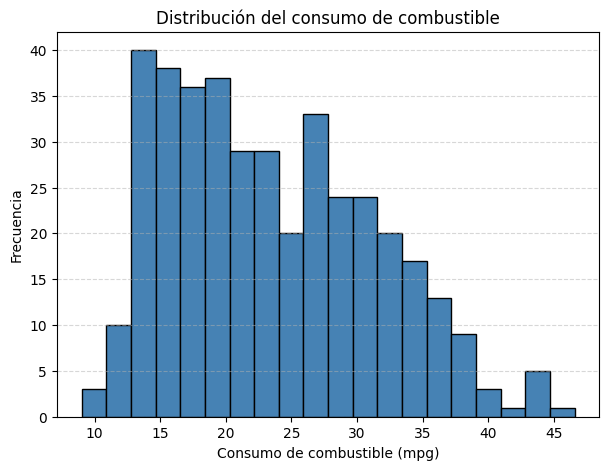

In [13]:
plt.figure(figsize=(7,5))
plt.hist(autos["mpg"], bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Consumo de combustible (mpg)")
plt.ylabel("Frecuencia")
plt.title("Distribución del consumo de combustible")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


**Interpretación:** la distribución de `mpg` está desplazada hacia la izquierda (la mayoría de los autos consume entre 15 y 25 mpg), con una cola hacia valores altos correspondiente a los modelos más eficientes.

### Diagramas de caja: `cylinders` y `origin`

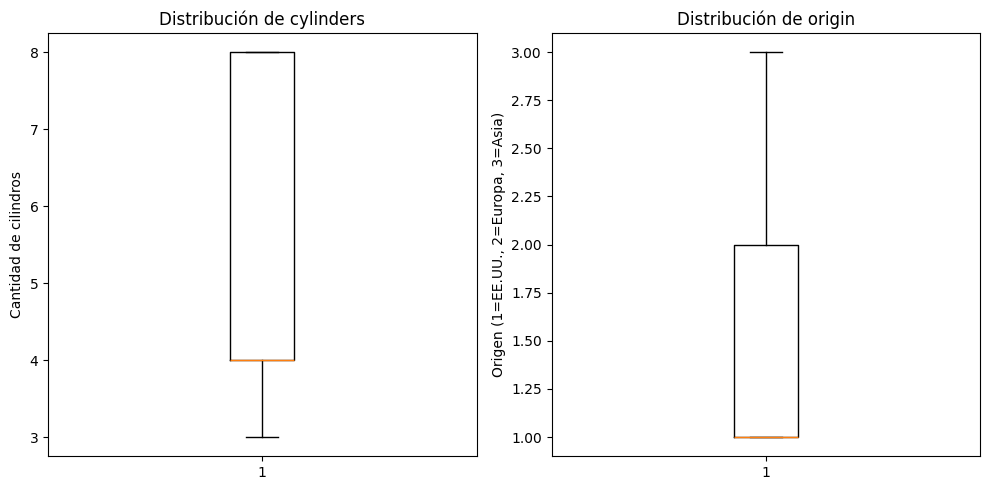

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].boxplot(autos["cylinders"])
axes[0].set_title("Distribución de cylinders")
axes[0].set_ylabel("Cantidad de cilindros")

axes[1].boxplot(autos["origin"])
axes[1].set_title("Distribución de origin")
axes[1].set_ylabel("Origen (1=EE.UU., 2=Europa, 3=Asia)")

plt.tight_layout()
plt.show()


**Interpretación:** `cylinders` toma valores discretos (mayormente 4, 6 y 8), con la mediana en 4; no se observan outliers según el criterio de caja y bigotes. `origin` está concentrado principalmente en el valor 1 (EE.UU.), lo cual se refleja en una caja angosta y desplazada hacia ese valor.

### Distribución de automóviles por año de modelo y origen

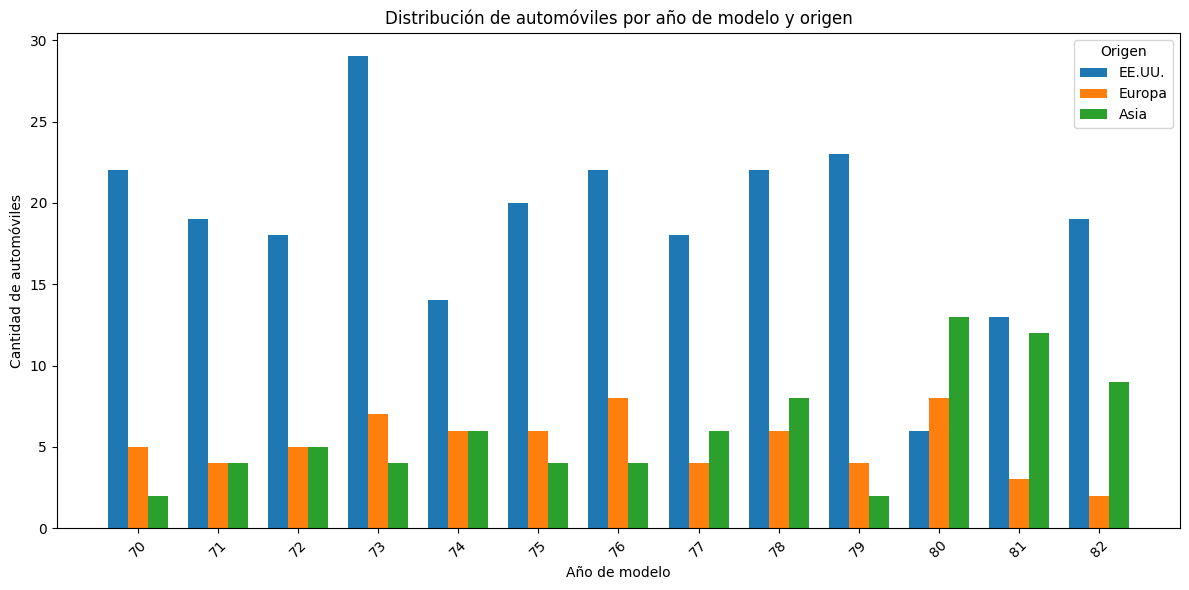

In [15]:
tabla_cruzada = pd.crosstab(autos["model_year"], autos["origin"])
tabla_cruzada.columns = ["EE.UU.", "Europa", "Asia"]

años = tabla_cruzada.index.values
x = np.arange(len(años))
ancho = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - ancho, tabla_cruzada["EE.UU."], width=ancho, label="EE.UU.")
plt.bar(x, tabla_cruzada["Europa"], width=ancho, label="Europa")
plt.bar(x + ancho, tabla_cruzada["Asia"], width=ancho, label="Asia")

plt.xlabel("Año de modelo")
plt.ylabel("Cantidad de automóviles")
plt.title("Distribución de automóviles por año de modelo y origen")
plt.xticks(x, años, rotation=45)
plt.legend(title="Origen")
plt.tight_layout()
plt.show()


**Interpretación:** a lo largo de los años del dataset (1970-1982), los automóviles de origen estadounidense predominan en casi todos los años, aunque se observa una presencia creciente de autos de origen japonés y europeo hacia los últimos años del período, coincidiendo con la crisis del petróleo de los años 70 y la mayor demanda de autos más eficientes.